In [1]:
import os
import cv2
import re
import numpy as np
import matplotlib.pyplot as plt
import warnings
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
plt.style.use('default')

In [2]:
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

def compute_tsr_derivatives(thermal_seq, poly_degree=5):
    T, H, W = thermal_seq.shape
    time_steps = np.arange(1, T + 1)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        log_t = np.log(time_steps)
        log_T_flat = np.log(np.maximum(thermal_seq.reshape(T, -1), 1e-6))

    print(f"Fitting Polynomials (Degree {poly_degree}) across {H*W} pixels...")
    coeffs = np.polyfit(log_t, log_T_flat, deg=poly_degree)
    
    powers_d1 = np.arange(poly_degree, 0, -1)[:, np.newaxis]
    d1_coeffs = coeffs[:-1] * powers_d1
    
    powers_d2 = np.arange(poly_degree - 1, 0, -1)[:, np.newaxis]
    d2_coeffs = d1_coeffs[:-1] * powers_d2
    
    d1_frames, d2_frames = [], []

    for t_val in log_t:
        f1 = np.zeros(H * W)
        for c in d1_coeffs: 
            f1 = f1 * t_val + c
        d1_frames.append(f1.reshape(H, W))
        
        f2 = np.zeros(H * W)
        for c in d2_coeffs: 
            f2 = f2 * t_val + c
        d2_frames.append(f2.reshape(H, W))
        
    return np.stack(d1_frames).astype(np.float32), np.stack(d2_frames).astype(np.float32)

In [3]:
dataset_path = "./dataset/" 
orig_dir = os.path.join(dataset_path, 'originalData')
mask_dir = os.path.join(dataset_path, 'annotatedData')

orig_files = sorted([f for f in os.listdir(orig_dir) if not f.startswith('.')], key=natural_sort_key)
mask_files = sorted([f for f in os.listdir(mask_dir) if not f.startswith('.')], key=natural_sort_key)

thermal_list, mask_list = [], []
IMG_SIZE = 128

In [4]:
for fname in orig_files:
    img = cv2.imread(os.path.join(orig_dir, fname), cv2.IMREAD_GRAYSCALE)
    m_img = cv2.imread(os.path.join(mask_dir, fname), cv2.IMREAD_GRAYSCALE)
    
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    m_img = cv2.resize(m_img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    
    thermal_list.append(img)
    _, binary = cv2.threshold(m_img, 1, 255, cv2.THRESH_BINARY)
    mask_list.append(binary / 255.0)

In [5]:
thermal_volume = np.stack(thermal_list, axis=0).astype(np.float32)
mask_volume = np.stack(mask_list, axis=0).astype(np.float32)

tsr_d1, tsr_d2 = compute_tsr_derivatives(thermal_volume)

Fitting Polynomials (Degree 5) across 16384 pixels...


In [6]:
def window_partition3d(x, window_size):
    B, D, H, W, C = x.shape
    x = x.view(B, D // window_size[0], window_size[0], 
                  H // window_size[1], window_size[1], 
                  W // window_size[2], window_size[2], C)
    windows = x.permute(0, 1, 3, 5, 2, 4, 6, 7).contiguous().view(-1, window_size[0]*window_size[1]*window_size[2], C)
    return windows

def window_reverse3d(windows, window_size, B, D, H, W):
    C = windows.shape[-1]
    x = windows.view(B, D // window_size[0], H // window_size[1], W // window_size[2], 
                     window_size[0], window_size[1], window_size[2], C)
    x = x.permute(0, 1, 4, 2, 5, 3, 6, 7).contiguous().view(B, D, H, W, C)
    return x

class WindowAttention3D(nn.Module):
    def __init__(self, dim, window_size, num_heads):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2 * window_size[0] - 1) * (2 * window_size[1] - 1) * (2 * window_size[2] - 1), num_heads))

        coords_d = torch.arange(self.window_size[0])
        coords_h = torch.arange(self.window_size[1])
        coords_w = torch.arange(self.window_size[2])
        coords = torch.stack(torch.meshgrid([coords_d, coords_h, coords_w], indexing='ij'))
        coords_flatten = torch.flatten(coords, 1)
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()
        
        relative_coords[:, :, 0] += self.window_size[0] - 1
        relative_coords[:, :, 1] += self.window_size[1] - 1
        relative_coords[:, :, 2] += self.window_size[2] - 1
        relative_coords[:, :, 0] *= (2 * self.window_size[1] - 1) * (2 * self.window_size[2] - 1)
        relative_coords[:, :, 1] *= 2 * self.window_size[2] - 1
        
        self.register_buffer("relative_position_index", relative_coords.sum(-1))

        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)
        nn.init.trunc_normal_(self.relative_position_bias_table, std=.02)

    def forward(self, x):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        q = q * self.scale
        attn = (q @ k.transpose(-2, -1))

        relative_position_bias = self.relative_position_bias_table[self.relative_position_index.view(-1)].view(
            self.window_size[0] * self.window_size[1] * self.window_size[2],
            self.window_size[0] * self.window_size[1] * self.window_size[2], -1)
        relative_position_bias = relative_position_bias.permute(2, 0, 1).contiguous()
        attn = attn + relative_position_bias.unsqueeze(0)

        attn = torch.softmax(attn, dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        return self.proj(x)

class SwinTransformerBlock3D(nn.Module):
    def __init__(self, dim, num_heads, window_size=(4, 4, 4), shift_size=(0, 0, 0)):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.shift_size = shift_size

        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention3D(dim, window_size=self.window_size, num_heads=num_heads)
        self.norm2 = nn.LayerNorm(dim)
        
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, x):
        B, D, H, W, C = x.shape
        shortcut = x

        x = self.norm1(x)

        if any(i > 0 for i in self.shift_size):
            shifted_x = torch.roll(x, shifts=(-self.shift_size[0], -self.shift_size[1], -self.shift_size[2]), dims=(1, 2, 3))
        else:
            shifted_x = x

        x_windows = window_partition3d(shifted_x, self.window_size)
        attn_windows = self.attn(x_windows)
        shifted_x = window_reverse3d(attn_windows, self.window_size, B, D, H, W)

        if any(i > 0 for i in self.shift_size):
            x = torch.roll(shifted_x, shifts=self.shift_size, dims=(1, 2, 3))
        else:
            x = shifted_x

        x = shortcut + x
        x = x + self.mlp(self.norm2(x))
        return x

class PatchEmbed3D(nn.Module):
    def __init__(self, patch_size=(1, 4, 4), in_chans=3, embed_dim=96):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv3d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        return x.permute(0, 2, 3, 4, 1) # B, D, Wh, Ww, C

class PatchMerging3D(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = nn.LayerNorm(4 * dim)

    def forward(self, x):
        B, D, H, W, C = x.shape
        x0 = x[:, :, 0::2, 0::2, :]
        x1 = x[:, :, 1::2, 0::2, :]
        x2 = x[:, :, 0::2, 1::2, :]
        x3 = x[:, :, 1::2, 1::2, :]
        x = torch.cat([x0, x1, x2, x3], -1)
        return self.reduction(self.norm(x))

class VideoSwinTransformer(nn.Module):
    def __init__(self, in_chans=3, embed_dim=96, depths=[2, 2, 6, 2], num_heads=[3, 6, 12, 24], 
                 window_size=(4, 4, 4), patch_size=(1, 4, 4)):
        super().__init__()
        self.num_layers = len(depths)
        self.patch_embed = PatchEmbed3D(patch_size, in_chans, embed_dim)
        
        self.layers = nn.ModuleList()
        for i_layer in range(self.num_layers):
            layer_dim = int(embed_dim * 2 ** i_layer)
            blocks = nn.ModuleList([
                SwinTransformerBlock3D(
                    dim=layer_dim, num_heads=num_heads[i_layer], window_size=window_size,
                    shift_size=(0, 0, 0) if (i % 2 == 0) else (window_size[0]//2, window_size[1]//2, window_size[2]//2)
                ) for i in range(depths[i_layer])
            ])
            downsample = PatchMerging3D(layer_dim) if (i_layer < self.num_layers - 1) else nn.Identity()
            self.layers.append(nn.ModuleDict({'blocks': blocks, 'downsample': downsample}))

    def forward(self, x):
        x = self.patch_embed(x)
        outs = []
        for layer in self.layers:
            for block in layer['blocks']:
                x = block(x)
            outs.append(x.permute(0, 4, 1, 2, 3)) # Back to [B, C, T, H, W]
            x = layer['downsample'](x)
        return outs

In [7]:
class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch), 
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch), 
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class VideoSwinUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()
        self.encoder = VideoSwinTransformer(
            in_chans=in_ch, embed_dim=96, depths=[2, 2, 6, 2], 
            num_heads=[3, 6, 12, 24], window_size=(4, 4, 4), patch_size=(1, 4, 4)
        )
        
        self.up1 = nn.ConvTranspose3d(768, 384, kernel_size=(1, 2, 2), stride=(1, 2, 2))
        self.conv1 = DoubleConv3D(384 + 384, 384)
        
        self.up2 = nn.ConvTranspose3d(384, 192, kernel_size=(1, 2, 2), stride=(1, 2, 2))
        self.conv2 = DoubleConv3D(192 + 192, 192)
        
        self.up3 = nn.ConvTranspose3d(192, 96, kernel_size=(1, 2, 2), stride=(1, 2, 2))
        self.conv3 = DoubleConv3D(96 + 96, 96)
        
        self.up4 = nn.ConvTranspose3d(96, 64, kernel_size=(1, 4, 4), stride=(1, 4, 4))
        self.conv4 = DoubleConv3D(64, 64)
        
        self.outc = nn.Conv3d(64, out_ch, kernel_size=1)

    def forward(self, x):
        features = self.encoder(x)
        f1, f2, f3, f4 = features
        
        x = self.up1(f4)
        x = torch.cat([f3, x], dim=1)
        x = self.conv1(x)
        
        x = self.up2(x)
        x = torch.cat([f2, x], dim=1)
        x = self.conv2(x)
        
        x = self.up3(x)
        x = torch.cat([f1, x], dim=1)
        x = self.conv3(x)
        
        x = self.up4(x)
        x = self.conv4(x)
        
        return self.outc(x)

In [8]:
class ThermoVideoDataset(Dataset):
    def __init__(self, raw, d1, d2, masks, seq_len=8): 
        self.raw, self.d1, self.d2, self.masks = raw, d1, d2, masks
        self.seq_len = seq_len
        
    def __len__(self): 
        return len(self.raw) - self.seq_len + 1
        
    def __getitem__(self, i):
        raw_seq = self.raw[i : i + self.seq_len]
        d1_seq = self.d1[i : i + self.seq_len]
        d2_seq = self.d2[i : i + self.seq_len]
        mask_seq = self.masks[i : i + self.seq_len]
        
        x = np.stack([raw_seq, d1_seq, d2_seq], axis=1) 
        x = np.transpose(x, (1, 0, 2, 3))
        y = mask_seq[np.newaxis, ...] 
        
        return torch.from_numpy(x).float(), torch.from_numpy(y).float()

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [10]:
SEQ_LEN = 8
BATCH_SIZE = 2 
EPOCHS = 20

In [11]:
model = VideoSwinUNet(in_ch=3, out_ch=1).to(device)

dataset = ThermoVideoDataset(thermal_volume, tsr_d1, tsr_d2, mask_volume, seq_len=SEQ_LEN)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = nn.BCEWithLogitsLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [12]:
loss_history = []

for epoch in range(EPOCHS):
    epoch_loss = 0
    model.train()
    
    for batch_idx, (data, target) in enumerate(loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data) 
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} - Average Loss: {avg_loss:.4f}")

Epoch 01/20 - Average Loss: 0.2962
Epoch 02/20 - Average Loss: 0.1201
Epoch 03/20 - Average Loss: 0.0587
Epoch 04/20 - Average Loss: 0.0320
Epoch 05/20 - Average Loss: 0.0189
Epoch 06/20 - Average Loss: 0.0121
Epoch 07/20 - Average Loss: 0.0080
Epoch 08/20 - Average Loss: 0.0056
Epoch 09/20 - Average Loss: 0.0041
Epoch 10/20 - Average Loss: 0.0030
Epoch 11/20 - Average Loss: 0.0022
Epoch 12/20 - Average Loss: 0.0016
Epoch 13/20 - Average Loss: 0.0012
Epoch 14/20 - Average Loss: 0.0009
Epoch 15/20 - Average Loss: 0.0010
Epoch 16/20 - Average Loss: 0.0006
Epoch 17/20 - Average Loss: 0.0005
Epoch 18/20 - Average Loss: 0.0004
Epoch 19/20 - Average Loss: 0.0003
Epoch 20/20 - Average Loss: 0.0003


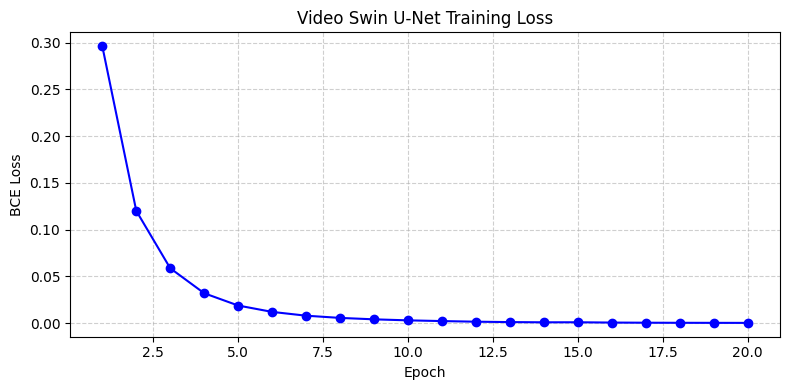

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), loss_history, marker='o', linestyle='-', color='b')
plt.title("Video Swin U-Net Training Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [14]:
model.eval()

total_frames = len(thermal_volume)

test_indices = [
    max(SEQ_LEN - 1, int(total_frames * 0.15)),
    max(SEQ_LEN - 1, int(total_frames * 0.25)),
    max(SEQ_LEN - 1, int(total_frames * 0.50))
]

In [15]:
predictions = []

with torch.no_grad():
    for idx in test_indices:
        seq_slice = slice(idx - SEQ_LEN + 1, idx + 1)
        
        sample_in = np.stack([
            thermal_volume[seq_slice], 
            tsr_d1[seq_slice], 
            tsr_d2[seq_slice]
        ], axis=1)
        
        sample_tensor = torch.from_numpy(np.transpose(sample_in, (1, 0, 2, 3))).unsqueeze(0).to(device)
        pred_seq_probs = torch.sigmoid(model(sample_tensor)).cpu().squeeze().numpy()
        pred_seq_mask = (pred_seq_probs > 0.5).astype(np.float32)
        predictions.append(pred_seq_mask[-1])

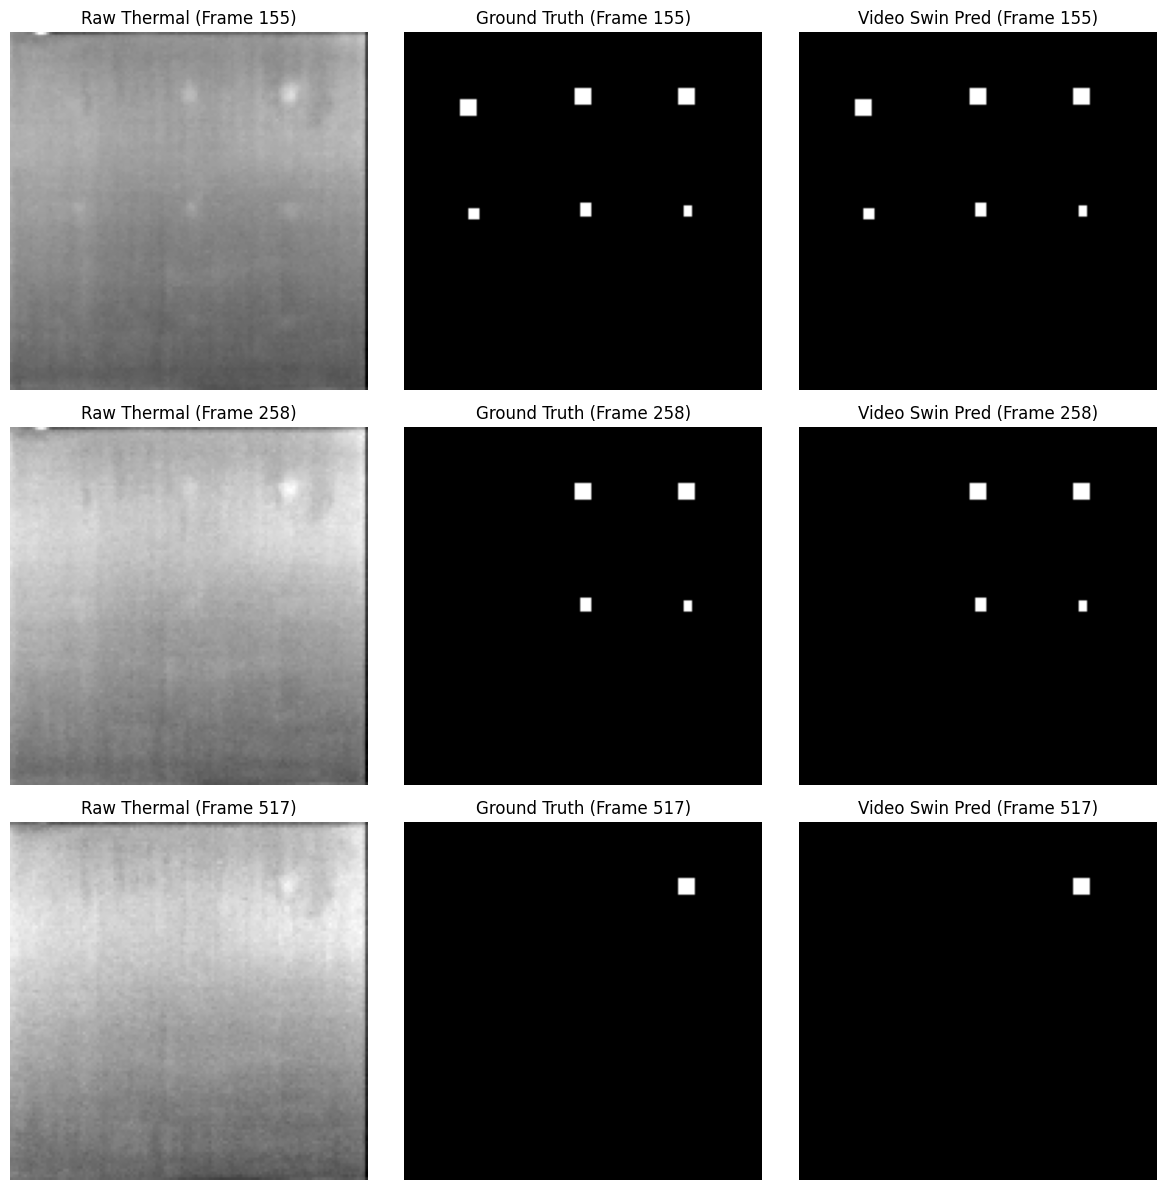

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row, idx in enumerate(test_indices):
    axes[row, 0].imshow(thermal_volume[idx], cmap='gray')
    axes[row, 0].set_title(f"Raw Thermal (Frame {idx})")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(mask_volume[idx], cmap='gray')
    axes[row, 1].set_title(f"Ground Truth (Frame {idx})")
    axes[row, 1].axis('off')

    axes[row, 2].imshow(predictions[row], cmap='gray')
    axes[row, 2].set_title(f"Video Swin Pred (Frame {idx})")
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()